# Introduction to TensorFlow & Keras — Part 1
### Layers, the Sequential API, and training your first model

This is a tutorial, not a challenge — the goal is to build a mental
model of what's actually happening when you write Keras code, one
piece at a time, before you ever train anything.

### Code rules for this notebook
1. Keep all your imports in the next cell.
2. Give variables names that say what they hold (`hidden_layer`, not `l1`).
3. Add type hints to every function you write.

In [2]:
!pip install tensorflow

  Using cached protobuf-7.36.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 1.2 MB/s eta 0:00:0000:01m0:13
Using cached protobuf-7.36.1-cp310-abi3-manylinux2014_x86_64.whl (343 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 1.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/14 [libclang]
    Found existing installation: protobuf 5.29.6━━━━━━━━━━━━━━━━━━  4/14 [protobuf]
    Uninstalling protobuf-5.29.6:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/14 [protobuf]
      Successfully uninstalled protobuf-5.29.6━━━━━━━━━━━━━━━━  4/14 [protobuf]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [tensorflow]4 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confli

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1789635012.924592   35568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789635012.928066   35568 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789635013.103993   35568 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789635020.574335   35568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0


## Step 1: What actually is TensorFlow?

TensorFlow is a library for building and training machine learning
models. At its core, everything in TensorFlow — every input, every
weight, every output — is stored as a **tensor**: a generalization of
a number, a list of numbers, and a grid of numbers, all in one
concept.

| Tensor rank | Example |
|---|---|
| 0 (scalar) | a single number, `5.0` |
| 1 (vector) | a list, `[1.0, 2.0, 3.0]` |
| 2 (matrix) | a grid, e.g. one grayscale image |
| 3+ | a stack of grids, e.g. a batch of images |

TensorFlow's other core job, alongside storing tensors, is tracking
every operation done to them so it can automatically compute
gradients later — the same chain-rule machinery you already worked
through by hand. Keras is TensorFlow's high-level API: it's the part
you'll actually type most of the time, and it's what the rest of this
notebook uses.

📖 [Tensors, explained (TensorFlow guide)](https://www.tensorflow.org/guide/tensor)

In [4]:
scalar = tf.constant(5.0)
vector = tf.constant([1.0, 2.0, 3.0])
matrix = tf.constant([[1.0, 2.0], [3.0, 4.0]])

for name, t in [("scalar", scalar), ("vector", vector), ("matrix", matrix)]:
    print(f"{name}: shape={t.shape}, rank={t.ndim}")

scalar: shape=(), rank=0
vector: shape=(3,), rank=1
matrix: shape=(2, 2), rank=2


E0000 00:00:1789635167.468496   35568 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789635167.469187   40714 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1789635167.486056   35568 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Step 2: What is a layer?

A **layer** is the basic building block of a neural network in
Keras. Conceptually, it's nothing more than a function: you hand it
an input tensor, it does some transformation, and it hands back an
output tensor.

The most common layer, `Dense`, does exactly the same computation you
already derived by hand: $z = Wx + b$, then optionally squash it with
an activation function. Keras just handles the weights and the
computation for you.

📖 [Dense layer docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)

In [11]:
# A single layer, on its own -- not part of any model yet.
example_layer = layers.Dense(units=4, activation="relu", use_bias=True)  # HINT: pick any number of output units, e.g. 4

# A layer needs to actually be called on a tensor to do anything.
sample_input = tf.constant([[1.0, 2.0, 3.0]])  # shape (1, 3) -- one example, 3 features
sample_output = example_layer(
    inputs=sample_input,
    training=True
    )  # HINT: call the layer on sample_input, the same way you'd call a function

print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {sample_output.shape}")
print(sample_output)

Input shape:  (1, 3)
Output shape: (1, 4)
tf.Tensor([[0.         0.21378827 2.2650208  1.1385998 ]], shape=(1, 4), dtype=float32)


**🧠 Your turn:** The input above had 3 numbers and the output has a
different count. Where did that number come from — was it decided by
the input, or by something you chose when creating the layer?

_Write your answer here:_ `The output of shape (1,x) is the result from each of the neurones in our single layer. At first,I chose units=4, then 5, then 3, it means that our layer has x number if neurones.I am also guessing Dense function of Tensorflow provide a fully connected layer where each sample is processed in every neurone of the layer`

## Step 3: A few different types of layers

`Dense` is one layer type among many. Here are a handful you'll run
into constantly — you don't need to memorize these, just recognize
the names when you see them again:

| Layer | Roughly what it does |
|---|---|
| `Dense` | Every input connects to every output — the classic fully-connected layer |
| `Flatten` | Reshapes a multi-dimensional tensor (like a 28×28 image) into a flat vector |
| `Dropout` | Randomly zeroes out a fraction of values during training, to fight overfitting |
| `Conv2D` | Scans small local patches of an image looking for patterns — the workhorse of image models |
| `Activation` | Applies a nonlinearity (relu, sigmoid, softmax, ...) on its own, if you didn't bundle it into the layer before it |

You'll use `Dense` and `Dropout` in this notebook — the rest are
previews of what's coming later.

📖 [Full layers list (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/layers)

## Step 4: Combining layers — the Sequential API

A real network is just several layers chained together, where **the
output of one layer becomes the input to the next.** That's the whole
idea — nothing more mysterious than that.

Keras's `Sequential` API does exactly this wiring for you: you hand
it a list of layers, in order, and it connects output → input →
output → input all the way down.

📖 [The Sequential model (Keras docs)](https://www.tensorflow.org/guide/keras/sequential_model)

In [18]:
tiny_model = keras.Sequential([
    layers.Dense(4, activation="relu", input_shape=(3,)),
    layers.Dense(2, activation="relu"),  # HINT: any number of units
    layers.Dense(2, activation="softmax"),
])

tiny_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 2)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32 (128.00 B)

 Trainable params: 32 (128.00 B)

 Non-trainable params: 0 (0.00 B)

**🧠 Your turn:** Look at the `summary()` output above, specifically
the "Output Shape" column. Confirm out loud (or in writing) that each
layer's output shape matches the very next layer's expected input
size.

_Write your answer here:_ `Yes. Dense 1 outputs (None, 4), and Dense 2 takes those 4 values as its input; Dense 2 outputs (None, 4) again, which Dense 3 takes in and outputs (None, 2). Each layer's output width becomes the next layer's expected input width.`

## Step 5: When does Sequential actually shine?

Sequential is the right tool whenever your model is a **single input,
single output, straight-line stack** — no branches, no merging two
things together. That covers a surprising amount of real work: most
basic image classifiers and text classifiers start out exactly this
shape.

Below, a small real example: classify MNIST digit images using
nothing but a plain Sequential stack.

📖 [Dataset docs: tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data)

In [25]:
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

X_train = X_train_raw.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test = X_test_raw.reshape(-1, 28 * 28).astype("float32") / 255.0

digit_classifier = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(784,)),
    layers.Dense(10, activation="relu"),  # HINT: same activation as Step 4's output layer, and why
])

digit_classifier.summary()
#digit_classifier.predict(y_test)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

**🧠 Your turn:** This model has exactly one input (the image) and one
output (a digit guess). Can you think of a task where you'd need
*two* separate inputs feeding into one model — where Sequential would
no longer be enough? (We'll come back to this exact question with a
real example in the next notebook.)

_Write your answer here:_ `an image and a text question what color is the car?" both feed in, combined to produce one answer.`

## Step 6: Getting ready to train — loss and optimizers

Two more pieces before `digit_classifier` can actually learn anything:

- **Loss function** — same idea you already know: a number that says
  how wrong a prediction is. We'll use `sparse_categorical_crossentropy`,
  cross-entropy loss for the case where labels are plain integers
  (`3`, `7`, ...) rather than one-hot vectors.
- **Optimizer** — the algorithm that actually *uses* the gradients to
  update every weight. This is the part you already know as gradient
  descent — plain, stochastic, or mini-batch. An "optimizer" in Keras
  is just that update rule, packaged up.

📖 [Losses (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/losses) · [Optimizers overview (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)

## Step 7: Learning rate schedules

You already know the learning rate, $\eta$, controls how big a step
gradient descent takes. A **learning rate schedule** just means: don't
keep $\eta$ fixed for the entire training run — change it over time,
usually shrinking it as training goes on.

**Why shrink it?** Early in training, big steps are good — you're far
from any minimum, so you want to cover ground fast. Late in training,
big steps start overshooting the minimum and bouncing around it
instead of settling in. A smaller learning rate near the end lets the
model fine-tune instead of overshoot.

📖 [Learning rate schedules (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/schedules)

## Step 8: Meet Adam

Plain SGD uses the *same* learning rate for every weight, every step.
**Adam** is SGD's smarter cousin: it keeps a running average of each
weight's past gradients (a form of momentum) and automatically gives
each individual weight its own adapted learning rate — so you rarely
have to hand-tune $\eta$ yourself. It's the most common default
optimizer choice in practice today.

📖 [Adam optimizer docs](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) · [Original Adam paper (Kingma & Ba, 2014)](https://arxiv.org/abs/1412.6980)

## Step 9: Two more tools — Dropout and EarlyStopping

Quickly, before training:

- **Dropout** randomly turns off a fraction of neurons during
  training, so the network can't lean too hard on any single one.
- **EarlyStopping** watches validation performance and stops training
  the moment it stops improving, instead of running a fixed number of
  epochs regardless.

📖 [Dropout docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) · [EarlyStopping docs](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)

In [30]:
digit_classifier = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(784,)),
    layers.Dropout(0.1),  # HINT: a fraction between 0 and 1, e.g. 0.2
    layers.Dense(10, activation="softmax"),
])

digit_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002),  # HINT: a small number, e.g. 0.001 is Adam's usual default
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

/home/bode-murairi/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 10: Train it

Time to actually call `.fit()`. We'll hold out 10% of the training
data as **validation data** — examples the model never trains on,
checked after every epoch, purely so we can watch for overfitting as
it happens. `epochs` is set high on purpose here — `EarlyStopping`
will cut training short once validation accuracy stops improving.

In [33]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # HINT: which metric should it watch to decide when to stop?
    patience=3,
    restore_best_weights=True,
)

history = digit_classifier.fit(
    X_train, y_train,
    validation_split=0.1,  # HINT: 10%, as a fraction between 0 and 1
    epochs=30,
    batch_size=128,
    callbacks=[early_stopping],
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8926 - loss: 0.3686 - val_accuracy: 0.9617 - val_loss: 0.1509
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9476 - loss: 0.1802 - val_accuracy: 0.9693 - val_loss: 0.1117
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9595 - loss: 0.1377 - val_accuracy: 0.9742 - val_loss: 0.0942
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9668 - loss: 0.1130 - val_accuracy: 0.9750 - val_loss: 0.0859
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9708 - loss: 0.0987 - val_accuracy: 0.9733 - val_loss: 0.0880
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9727 - loss: 0.0874 - val_accuracy: 0.9735 - val_loss: 0.0858
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9755 - loss: 0.0793 - val_accuracy: 0.9762 - val_loss: 0.0795
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9773 - loss: 0.0728 - val_accuracy: 0.

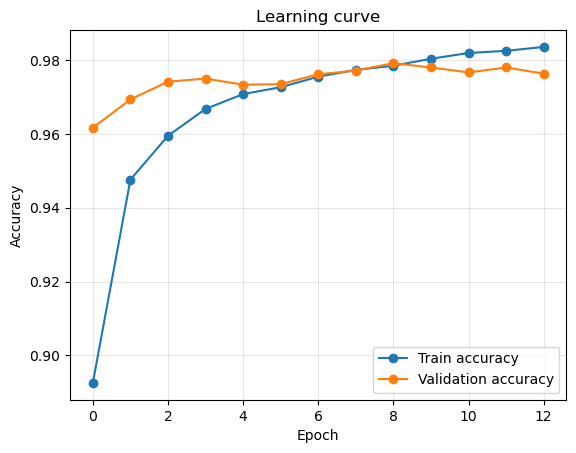

In [34]:
plt.plot(history.history["accuracy"], marker="o", label="Train accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**🧠 Your turn:** Look at the curve. Is train or validation accuracy
higher? Is the gap between them growing, shrinking, or roughly flat
across training?

_Write your answer here:_ `Validation accuracy was higher than the train accuracy at start, then start lowering down until it became roughly equal to the train accuracy, then the train accuracy became slighly higher. But the difference is slighly negligible`

## Wrap-up

You've now gone from "what is a tensor" to training a real model on
real digits, using nothing but `Sequential`. In the next notebook,
we'll pick up exactly where Step 5 left off — what Sequential
*can't* express — and build the multi-input model you sketched out
by hand, before pushing this classifier further.